# Intrusion Error Rate

> Measure and visualize the rate of extra-list intrusion errors by study position.

An intrusion error occurs when a participant recalls an item that was not presented on the current study list. The intrusion error rate curve plots the proportion of intrusion errors at each output position, revealing where in the recall sequence participants are most likely to produce extra-list items.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.intrusion_error_rate import (
    trial_intrusion_error_rate,
    intrusion_error_rate,
    plot_intrusion_error_rate,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "Intrusion Error Rate"
data_path = "data/Gordon2021.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "jnp.logical_and(data['condition'] == 2, data['listLength'] == 7)"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

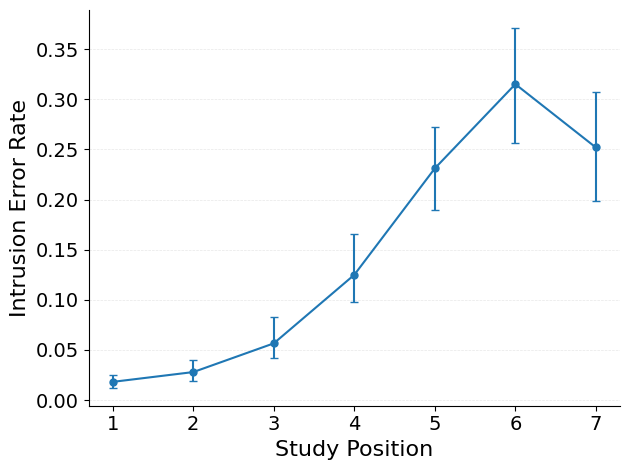

In [5]:
#| code-summary: Plot intrusion error rate
#| label: fig-intrusion-error-rate
#| fig-cap: "Intrusion error rate by study position."
plot_intrusion_error_rate(datasets=data, trial_masks=trial_mask)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_intrusion_error_rate)

---

### plot_intrusion_error_rate

>      plot_intrusion_error_rate (datasets:Union[Sequence[jaxcmr.typing.RecallDa
>                                 taset],jaxcmr.typing.RecallDataset], trial_mas
>                                 ks:Union[Sequence[jaxtyping.Bool[Array,'trial_
>                                 count']],jaxtyping.Bool[Array,'trial_count']],
>                                 color_cycle:Optional[list[str]]=None,
>                                 labels:Optional[Sequence[str]]=None,
>                                 contrast_name:Optional[str]=None, axis:Optiona
>                                 l[matplotlib.axes._axes.Axes]=None,
>                                 confidence_level:float=0.95)

*Plot intrusion error rate curves with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with intrusion error rate curves.** |

In [7]:
#| echo: false
show_doc(intrusion_error_rate)

---

### intrusion_error_rate

>      intrusion_error_rate (dataset:jaxcmr.typing.RecallDataset)

*Return position-specific intrusion error rate.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| **Returns** | **Float[Array, 'study_positions']** | **Mean intrusion rate at each study position.** |

In [8]:
# Items 1-3 studied; recall includes item 5 (intrusion) at position 2
recalls = jnp.array([1, 5, 3], dtype=jnp.int32)
presentations = jnp.array([1, 2, 3], dtype=jnp.int32)

result = trial_intrusion_error_rate(recalls, presentations)
assert jnp.array_equal(result, jnp.array([False, True, False]))

In [9]:
#| echo: false
show_doc(trial_intrusion_error_rate)

---

### trial_intrusion_error_rate

>      trial_intrusion_error_rate
>                                  (recalls:jaxtyping.Integer[Array,'recall_posi
>                                  tions'], presentations:jaxtyping.Integer[Arra
>                                  y,'study_positions'])

*Flag intrusion errors at each study position for one trial.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| recalls | Integer[Array, 'recall_positions'] | Recall sequence for a trial. 1-indexed; 0 pads. |
| presentations | Integer[Array, 'study_positions'] | Presented item IDs for the trial. 1-indexed. |
| **Returns** | **Bool[Array, 'study_positions']** | **True where the recalled item is not on the study list.** |

In [10]:
# No intrusions when all recalls are from the study list
result = trial_intrusion_error_rate(
    jnp.array([1, 2, 3], dtype=jnp.int32),
    jnp.array([1, 2, 3], dtype=jnp.int32),
)
assert jnp.array_equal(result, jnp.array([False, False, False]))